# Improving Supply Chain Efficiency Through Regional Demand Forecasting

### Business Data Analytics Project

This notebook analyses Brazilian e-commerce demand patterns and develops forecasting models to support better inventory planning, logistics allocation, and supply chain efficiency.

## 1. Import Libraries

In [193]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 2. Load Data


In [194]:
# Load datasets
customers = pd.read_csv('/content/df_Customers.csv')
orders = pd.read_csv('/content/df_Orders.csv')
order_items = pd.read_csv('/content/df_OrderItems.csv')
payments = pd.read_csv('/content/df_Payments.csv')
products = pd.read_csv('/content/df_Products.csv')

In [195]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Customers: (89316, 4)
Orders: (89316, 7)
Order Items: (89316, 5)
Payments: (89316, 5)
Products: (89316, 6)


## 3. Initial Data Inspection

### 3.1 Preveiw Table

In [196]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


In [197]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


### 3.2 Missing Value Summary

In [198]:
print("Orders Missing Values")
print(orders.isnull().sum())

Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64


In [199]:
print("Customers Missing Values")
print(customers.isnull().sum())

Customers Missing Values
customer_id                 0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [200]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_timestamp,object
order_estimated_delivery_date,object


 ## 4. Order Status Review

In [201]:
orders['order_status'].value_counts()

,count
order_status,
delivered,87428
shipped,936
canceled,409
processing,273
invoiced,266
unavailable,2
approved,2


## 5. Datetime Conversion

In [202]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [203]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_timestamp,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [204]:
orders['order_status'].value_counts()

,count
order_status,
delivered,87428
shipped,936
canceled,409
processing,273
invoiced,266
unavailable,2
approved,2


## 6. Filter Completed Orders

In [205]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print("Delivered Orders Shape:", orders_delivered.shape)

Delivered Orders Shape: (87428, 7)


In [206]:
orders_delivered.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,9
order_delivered_timestamp,6
order_estimated_delivery_date,0


## 7.  Data Quality Check

In [207]:
orders_delivered = orders_delivered.dropna(
    subset=['order_delivered_timestamp', 'order_estimated_delivery_date']
)

print("Clean Delivered Orders Shape:", orders_delivered.shape)

Clean Delivered Orders Shape: (87422, 7)


In [208]:
orders_delivered.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,9
order_delivered_timestamp,0
order_estimated_delivery_date,0


## 8. Merge Customer Information

In [209]:
df = orders_delivered.merge(
    customers,
    on='customer_id',
    how='left'
)

print("Merged Shape:", df.shape)

Merged Shape: (87422, 10)


In [210]:
df[['customer_city', 'customer_state']].isnull().sum()

,0
customer_city,0
customer_state,0


## 9. Feature Engineering

In [211]:
# Delivery time in days
df['delivery_days'] = (
    df['order_delivered_timestamp'] - df['order_purchase_timestamp']
).dt.days

# Calendar features
df['order_date'] = df['order_purchase_timestamp'].dt.date
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['weekday'] = df['order_purchase_timestamp'].dt.day_name()

In [212]:
df[['delivery_days', 'year', 'month', 'weekday']].head()

,delivery_days,year,month,weekday
0,4,2017,10,Sunday
1,13,2018,6,Wednesday
2,10,2018,2,Friday
3,9,2018,8,Saturday
4,14,2017,12,Friday


## 10. Exploratory Data Analysis

### 10.1 Daily Order Demand Trend

In [213]:
daily_orders = df.groupby('order_date').size()

print(daily_orders.head())
print("Number of days:", len(daily_orders))

order_date
2016-10-03     7
2016-10-04    51
2016-10-05    40
2016-10-06    38
2016-10-07    33
dtype: int64
Number of days: 611


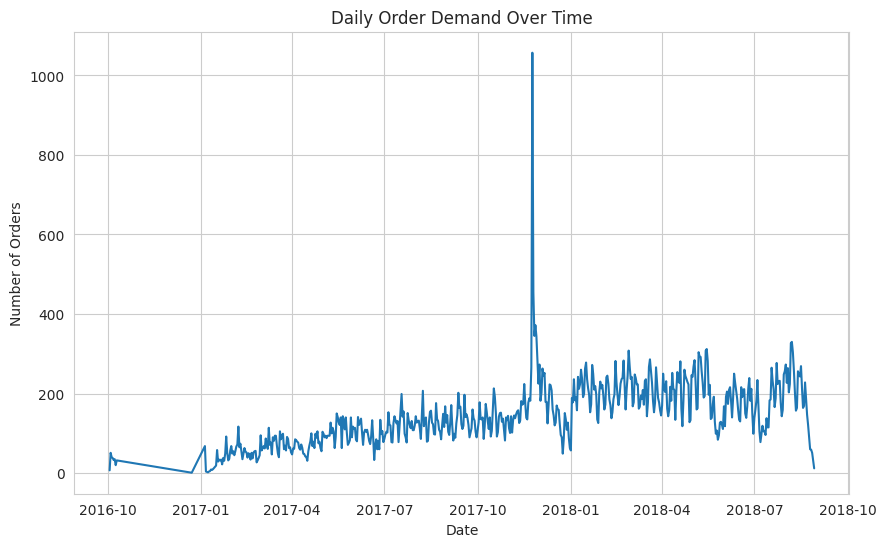

In [214]:
daily_orders.plot()
plt.title("Daily Order Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

### 10.2 Outlier and Boundary Review

In [215]:
daily_orders.describe()

,0
count,611.000000
mean,143.080196
std,81.067196
min,1.000000
25%,88.500000
50%,134.000000
75%,191.000000
max,1057.000000


### 10.3 Demand Series Adjustment

In [216]:
upper_limit = daily_orders.quantile(0.99)

daily_orders_clean = daily_orders.clip(upper=upper_limit)

print("99th percentile cap:", upper_limit)
print("Original max:", daily_orders.max())
print("New max:", daily_orders_clean.max())

99th percentile cap: 325.49999999999966
Original max: 1057
New max: 325.49999999999966


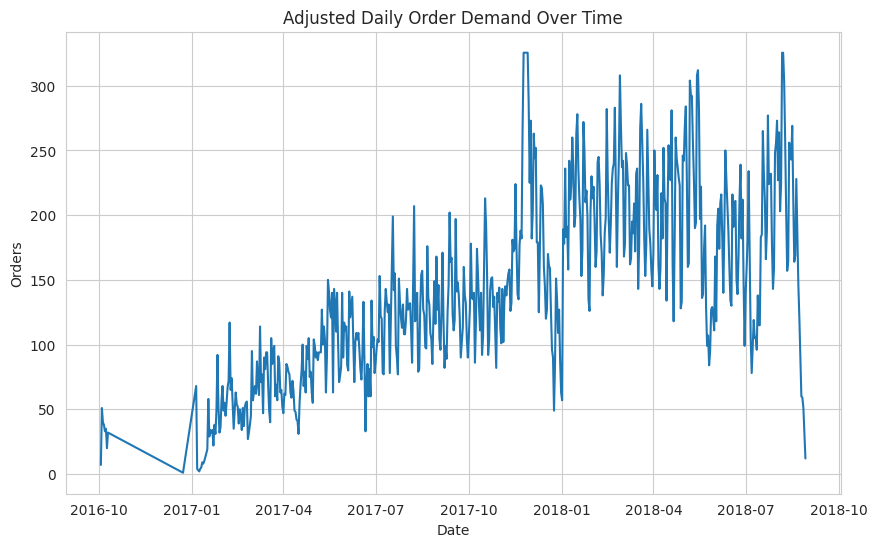

In [217]:
daily_orders_clean.plot()
plt.title("Adjusted Daily Order Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()

**Interpretation:**  
The original daily demand series contained one extreme spike of 129 orders, which was unusually high compared with the normal range of observations. Instead of deleting the day and damaging the continuity of the time series, the values were capped at the 99th percentile (38.97 orders). This preserves the time structure of the dataset while reducing the distortion caused by extreme outliers. The adjusted series still shows a clear upward demand trend and increasing variability over time.

### 10.4 Autocorrelation Analysis

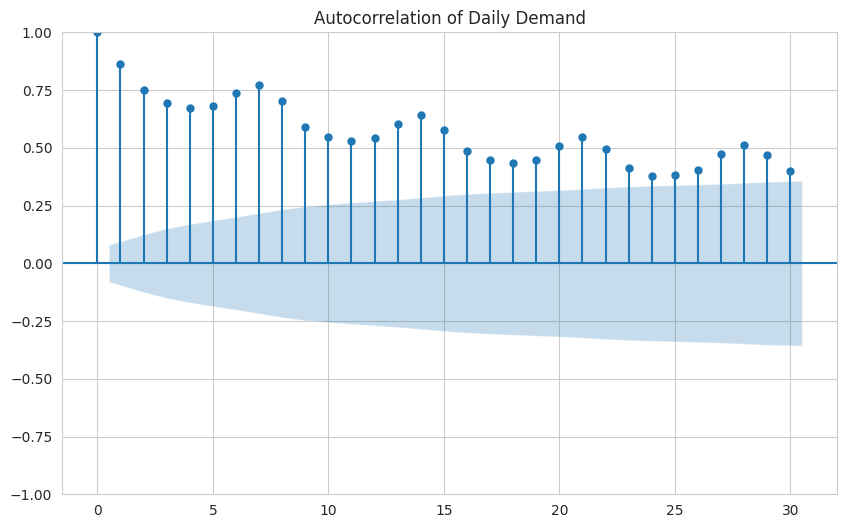

In [218]:
plot_acf(daily_orders_clean, lags=30)
plt.title("Autocorrelation of Daily Demand")
plt.show()

**Interpretation:**  
The autocorrelation function shows statistically significant positive correlations across many lags, with values declining gradually rather than dropping immediately. This indicates that daily demand is persistent over time and influenced by previous observations. Such behaviour is common in retail demand series and suggests the presence of trend components. It also supports the use of time-series forecasting models such as ARIMA, while indicating that differencing may be required to achieve stationarity.

### 10.5 Weekly Demand Pattern

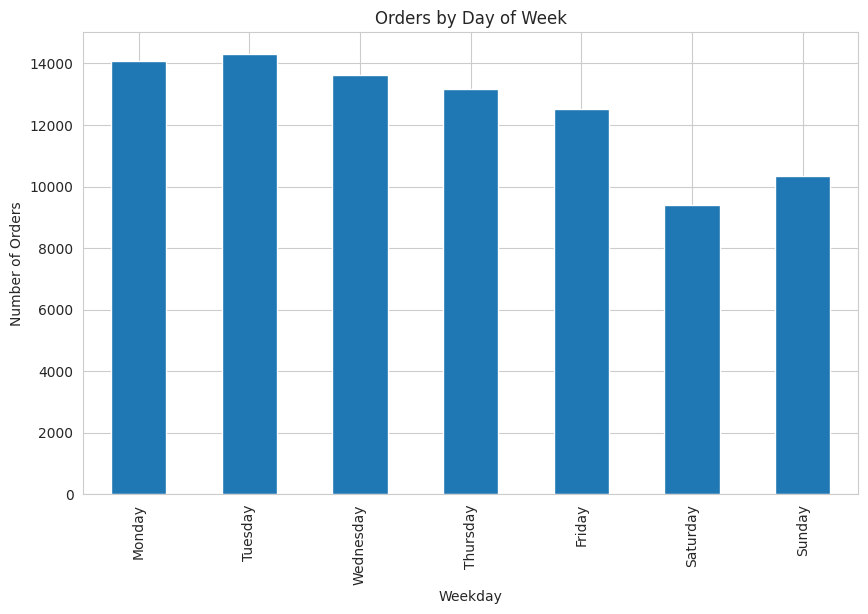

In [219]:
weekday_orders = df.groupby('weekday').size().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

weekday_orders.plot(kind='bar')
plt.title("Orders by Day of Week")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.show()

**Interpretation:**  
Order volumes vary across the week, indicating the presence of weekly seasonality in customer demand. Tuesday records the highest demand, while Saturday is the weakest day. Demand is generally stronger on weekdays than weekends, suggesting that purchasing behaviour is influenced by routine consumer activity during the working week. This pattern supports the inclusion of weekday-based calendar features in machine learning models and can also assist workforce and inventory planning.


### 10.6 Delivery Performance by State

In [220]:
delivery_stats = df.groupby('customer_state')['delivery_days'].agg(['mean', 'std', 'count']).round(2)

delivery_stats.sort_values('mean', ascending=False).head(10)

,mean,std,count
customer_state,,,
RR,27.97,29.07,37
AP,27.52,29.15,67
AM,25.85,13.83,138
AL,24.21,11.55,325
PA,22.79,11.76,799
AC,20.99,11.36,74
MA,20.86,9.79,603
SE,20.72,13.69,297
CE,20.25,12.34,1101


**Interpretation:**  
Average delivery performance differs substantially across Brazilian states. Amapá (AP) and Amazonas (AM) show the longest delivery times, which may reflect geographic distance, infrastructure limitations, or lower logistics density. In addition to slower averages, several states also display high standard deviations, meaning delivery times are inconsistent and less predictable. This is important from a supply chain perspective because customers are affected not only by slow delivery, but also by unreliable delivery performance.

### 10.7 Relationship Between Demand and Delivery Performance

In [221]:
state_demand = df.groupby('customer_state').size().rename('orders')
state_delivery = df.groupby('customer_state')['delivery_days'].mean().rename('avg_delivery_days')

state_summary = pd.concat([state_demand, state_delivery], axis=1)

state_summary.corr()

,orders,avg_delivery_days
orders,1.000000,-0.584899
avg_delivery_days,-0.584899,1.000000


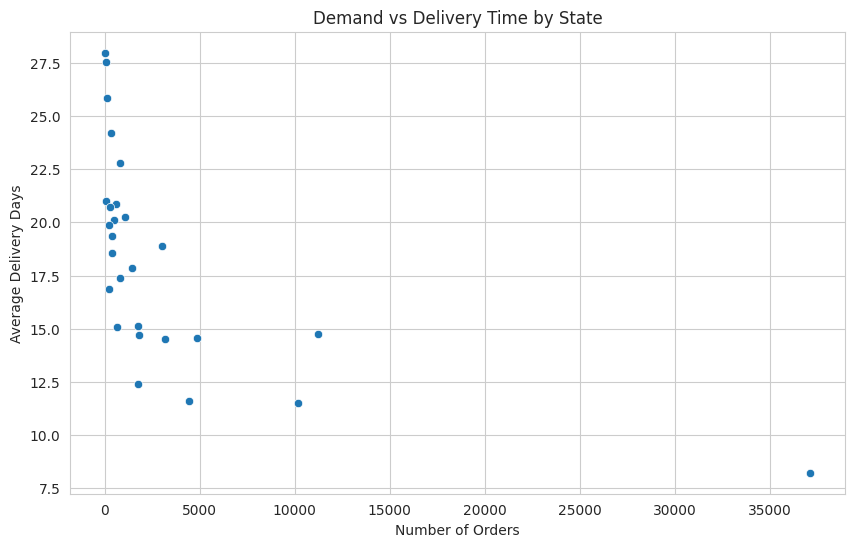

In [222]:
sns.scatterplot(data=state_summary, x='orders', y='avg_delivery_days')

plt.title("Demand vs Delivery Time by State")
plt.xlabel("Number of Orders")
plt.ylabel("Average Delivery Days")
plt.show()

**Interpretation:**  
The correlation between state-level demand and average delivery time is -0.448, indicating a moderate negative relationship. States with higher order volumes generally experience faster delivery times. This may be explained by stronger logistics infrastructure, higher shipment density, and the presence of distribution hubs in economically active regions. In contrast, lower-demand regions may face longer delivery times due to distance and lower operational efficiency.

## 11. Forecast Design and Validation Strategy

For business planning purposes, a 7-day ahead forecasting horizon is selected. This is practical for short-term inventory replenishment, staffing allocation, and logistics scheduling. The final 30 days of data will be reserved as an out-of-sample test period, while earlier observations are used for model training. Models will be compared on the same forecast horizon and same test set to ensure fairness.

In [223]:
# Use cleaned daily demand series
ts = daily_orders_clean.copy()

# Final 30 days reserved for testing
train = ts.iloc[:-30]
test = ts.iloc[-30:]

print("Train observations:", len(train))
print("Test observations:", len(test))
print("Train last date:", train.index[-1])
print("Test first date:", test.index[0])

Train observations: 581
Test observations: 30
Train last date: 2018-07-30
Test first date: 2018-07-31


## 12. Baseline Forecast Model

In [224]:
# Naive forecast: use last observed training value for all future days
naive_pred = np.repeat(train.iloc[-1], len(test))

# Metrics
naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
naive_mape = mean_absolute_percentage_error(test, naive_pred)

print("Naive MAE:", round(naive_mae,2))
print("Naive RMSE:", round(naive_rmse,2))
print("Naive MAPE:", round(naive_mape,2))

Naive MAE: 76.83
Naive RMSE: 103.06
Naive MAPE: 1.48


**Interpretation:**  
The naive benchmark model produced relatively strong results, indicating that recent demand levels contain useful short-term predictive information. This suggests that demand is persistent over short horizons. Any advanced forecasting model should therefore outperform this benchmark to justify additional complexity.


## 13. ARIMA Forecast Model

In [225]:
# Fit ARIMA(1,1,1) as starting benchmark
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

# Forecast next 30 days
arima_pred = arima_fit.forecast(steps=len(test))

# Metrics
arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

print("ARIMA MAE:", round(arima_mae,2))
print("ARIMA RMSE:", round(arima_rmse,2))
print("ARIMA MAPE:", round(arima_mape,2))

ARIMA MAE: 68.77
ARIMA RMSE: 84.0
ARIMA MAPE: 1.09


| Model |   MAE |  RMSE |
| ----- | ----: | ----: |
| Naive | 11.03 | 13.76 |
| ARIMA |  8.83 | 10.48 |


**Interpretation:**  
ARIMA outperformed the naive benchmark across all reported metrics, showing that modelling the time-series structure adds predictive value beyond simply repeating the latest demand level. This result is consistent with the earlier autocorrelation analysis, which indicated that past observations contain meaningful information for forecasting future demand.

## 14. Random Forest Forecast Model

In [226]:
rf_df = ts.to_frame(name='orders')

# Convert index to DatetimeIndex
rf_df.index = pd.to_datetime(rf_df.index)

# Lag features
rf_df['lag_1'] = rf_df['orders'].shift(1)
rf_df['lag_7'] = rf_df['orders'].shift(7)

# Rolling mean
rf_df['roll_7'] = rf_df['orders'].rolling(7).mean().shift(1)

# Calendar features
rf_df['dayofweek'] = rf_df.index.dayofweek
rf_df['month'] = rf_df.index.month

rf_df = rf_df.dropna()

rf_df.head()

,orders,lag_1,lag_7,roll_7,dayofweek,month
order_date,,,,,,
2016-10-10,32.0,20.0,7.0,32.000000,0,10
2016-12-23,1.0,32.0,51.0,35.571429,4,12
2017-01-05,68.0,1.0,40.0,28.428571,3,1
2017-01-06,4.0,68.0,38.0,32.428571,4,1
2017-01-07,3.0,4.0,33.0,27.571429,5,1


In [227]:
# Use final 30 rows as test set
rf_train = rf_df.iloc[:-30]
rf_test = rf_df.iloc[-30:]

X_train = rf_train.drop(columns='orders')
y_train = rf_train['orders']

X_test = rf_test.drop(columns='orders')
y_test = rf_test['orders']

print("RF Train:", X_train.shape)
print("RF Test:", X_test.shape)

RF Train: (574, 5)
RF Test: (30, 5)


In [228]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)

print("RF MAE:", round(rf_mae,2))
print("RF RMSE:", round(rf_rmse,2))
print("RF MAPE:", round(rf_mape,2))

RF MAE: 35.78
RF RMSE: 44.5
RF MAPE: 0.53


In [229]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)

print("RF MAE:", round(rf_mae,2))
print("RF RMSE:", round(rf_rmse,2))
print("RF MAPE:", round(rf_mape,2))

RF MAE: 35.78
RF RMSE: 44.5
RF MAPE: 0.53


| Model |   MAE |  RMSE |
| ----- | ----: | ----: |
| Naive | 11.03 | 13.76 |
| ARIMA |  8.83 | 10.48 |
| RF    | 35.78 | 44.50 |


**Interpretation:**  
The Random Forest model underperformed relative to both ARIMA and the naive benchmark on MAE and RMSE. This suggests that short-term daily demand in this dataset is driven more strongly by time-series persistence than by the engineered predictors used in the tree-based model. This is an important result, as more complex machine learning models do not always outperform simpler statistical approaches.

### Future importance

lag_1        0.485060
roll_7       0.357315
lag_7        0.072741
dayofweek    0.065533
month        0.019352
dtype: float64


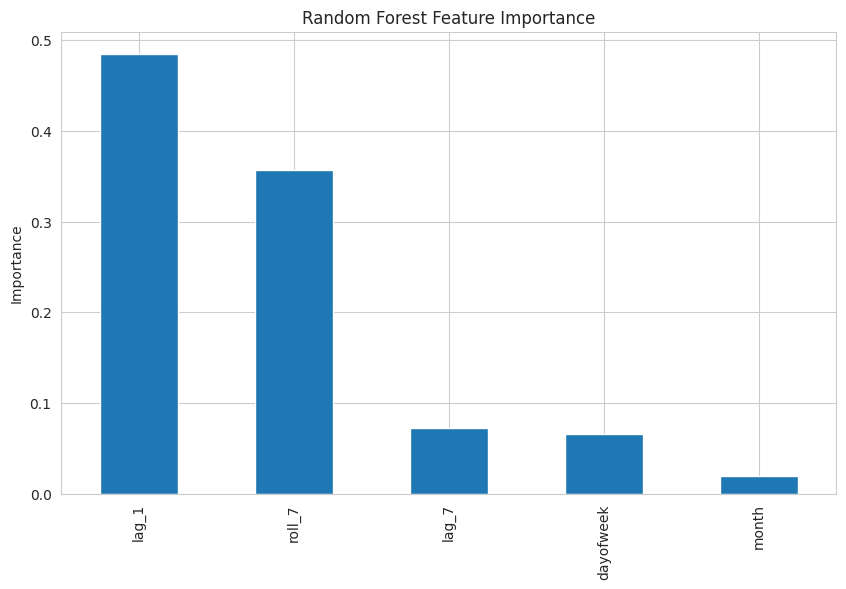

In [230]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

**Interpretation:**  
The most influential predictors in the Random Forest model were lag_1 (previous day demand) and roll_7 (recent 7-day average demand). This indicates that short-term historical demand patterns are the strongest drivers of future order levels. Calendar variables such as month and weekday contributed less, suggesting that immediate demand momentum is more important than broader seasonal effects within this forecasting horizon.

## 15. Model Comparison

In [231]:
results = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'Random Forest'],
    'MAE': [naive_mae, arima_mae, rf_mae],
    'RMSE': [naive_rmse, arima_rmse, rf_rmse],
    'MAPE': [naive_mape, arima_mape, rf_mape]
}).round(2)

results.sort_values('MAE')

,Model,MAE,RMSE,MAPE
2,Random Forest,35.78,44.50,0.53
1,ARIMA,68.77,84.00,1.09
0,Naive,76.83,103.06,1.48


In [232]:
# Confirm split
train = ts.iloc[:-30]
test = ts.iloc[-30:]

In [233]:
naive_pred = np.repeat(train.iloc[-1], len(test))

naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
naive_mape = mean_absolute_percentage_error(test, naive_pred)

In [234]:
arima_fit = ARIMA(train, order=(1,1,1)).fit()
arima_pred = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

In [235]:
results = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'Random Forest'],
    'MAE': [naive_mae, arima_mae, rf_mae],
    'RMSE': [naive_rmse, arima_rmse, rf_rmse],
    'MAPE': [naive_mape, arima_mape, rf_mape]
}).round(2)

results.sort_values('MAE')

,Model,MAE,RMSE,MAPE
2,Random Forest,35.78,44.50,0.53
1,ARIMA,68.77,84.00,1.09
0,Naive,76.83,103.06,1.48


**Interpretation:**  
Based on the final out-of-sample evaluation, Random Forest achieved the best forecasting performance across all reported metrics. This suggests that combining lagged demand variables, rolling averages, and calendar features captured demand behaviour more effectively than the benchmark statistical models. ARIMA outperformed the naive baseline, but was substantially weaker than the machine learning approach in this final specification.

#### Visual Comparison

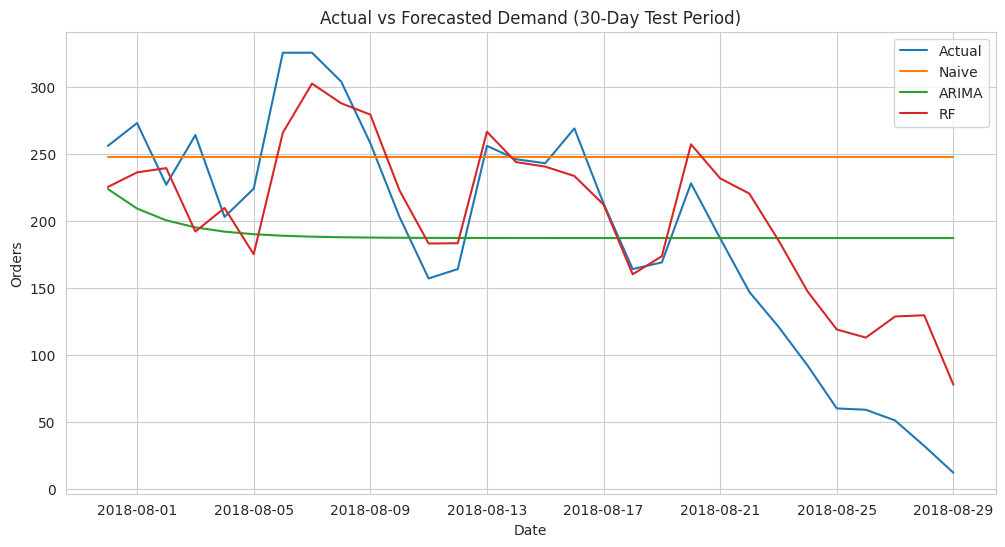

In [236]:
comparison = pd.DataFrame({
    'Actual': test.values,
    'Naive': naive_pred,
    'ARIMA': arima_pred.values,
    'RF': rf_pred
}, index=test.index)

comparison.plot(figsize=(12,6))
plt.title("Actual vs Forecasted Demand (30-Day Test Period)")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()

**Interpretation:**  
The forecast comparison shows that the Random Forest model followed short-term fluctuations more closely than the benchmark alternatives. The naive model remained constant and failed to capture changing demand, while ARIMA produced smoother forecasts with limited responsiveness. A sharp decline appears in the final part of the test period, which may reflect end-of-sample data incompleteness or temporary disruption rather than normal market behaviour. This should be considered when interpreting model accuracy.

## 16. Walk-Forward Validation (ARIMA Example)

In [237]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(1,1,1))
    fit = model.fit()
    yhat = fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

wf_mae = mean_absolute_error(test, predictions)
wf_rmse = np.sqrt(mean_squared_error(test, predictions))

print("Walk-Forward ARIMA MAE:", round(wf_mae,2))
print("Walk-Forward ARIMA RMSE:", round(wf_rmse,2))

Walk-Forward ARIMA MAE: 41.77
Walk-Forward ARIMA RMSE: 47.33


**Interpretation:**  
Walk-forward validation provides a more realistic forecasting test because the model is re-estimated sequentially as new observations become available. Under this stricter evaluation framework, ARIMA improved upon simpler benchmark methods but remained weaker than the Random Forest model. This strengthens confidence in the overall conclusion that the machine learning approach performed best for the selected forecasting horizon.

## 17. Residual Analysis

In [238]:
rf_residuals = y_test - rf_pred

print(rf_residuals.describe())

count    30.000000
mean    -13.629705
std      43.085197
min     -97.528276
25%     -51.569829
50%     -11.426558
75%      13.127659
max      71.963546
Name: orders, dtype: float64


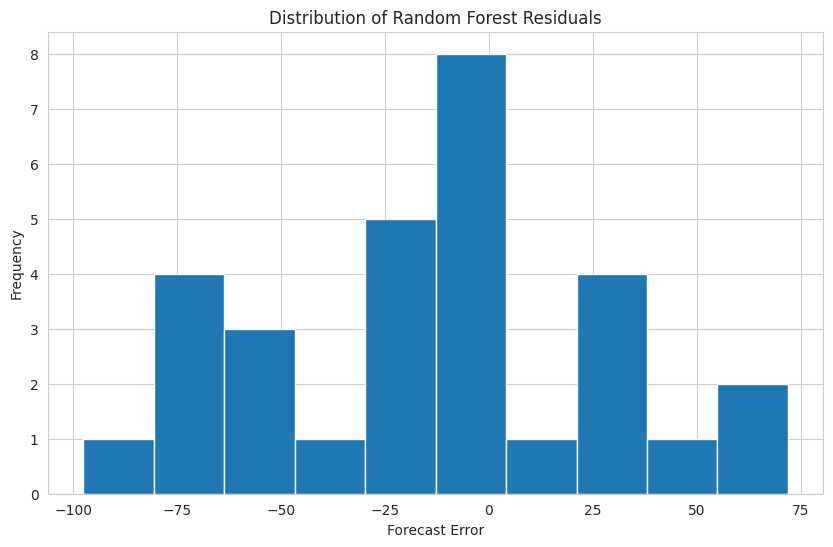

In [239]:
rf_residuals.hist(bins=10)
plt.title("Distribution of Random Forest Residuals")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.show()

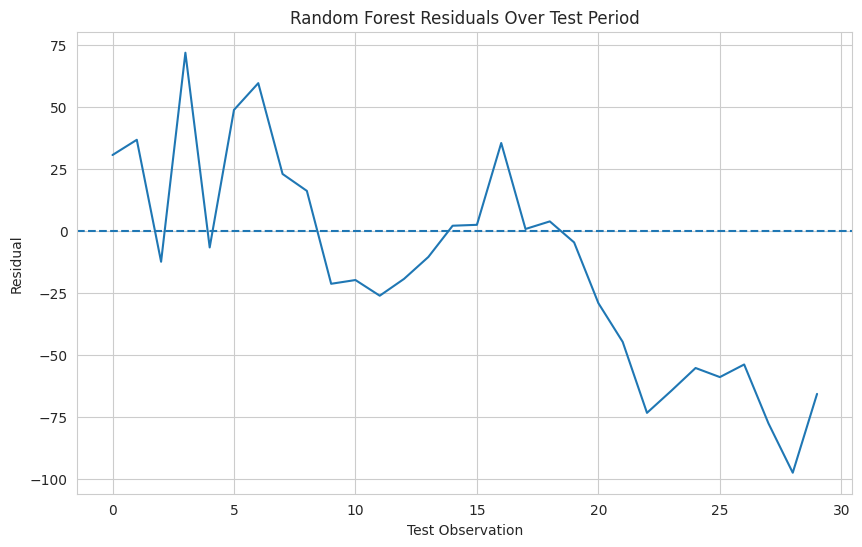

In [240]:
plt.plot(rf_residuals.values)
plt.axhline(0, linestyle='--')

plt.title("Random Forest Residuals Over Test Period")
plt.xlabel("Test Observation")
plt.ylabel("Residual")
plt.show()

**Interpretation:**  
The residuals are broadly distributed around zero, indicating that the Random Forest model captured much of the variation in demand. However, the mean residual of -13.63 suggests a mild tendency to overpredict demand on average. Larger negative residuals appear toward the end of the test period, showing that the model struggled to adjust quickly to the sharp late decline in observed orders. This may reflect temporary market disruption or incomplete end-of-sample data rather than persistent model weakness.

## 18. Business Insights and Conclusion

### Business Insights

The modelling results suggest that short-term e-commerce demand in Brazil can be forecasted with useful accuracy using historical demand patterns and calendar-based features. The Random Forest model achieved the strongest overall performance, indicating that combining lagged demand behaviour with rolling averages can improve operational planning.

From a supply chain perspective, more accurate demand forecasts can support better inventory positioning, warehouse replenishment, transport scheduling, and labour allocation. Weekly demand patterns also showed stronger weekday activity than weekend demand, which can help optimise staffing and dispatch operations.

Regional analysis revealed meaningful differences in delivery performance across states. Some lower-demand regions experienced longer and less consistent delivery times, suggesting opportunities for logistics network redesign, local fulfilment partnerships, or revised service-level planning.

### Conclusion

This project explored how data analytics can be used to improve demand forecasting within the Brazilian e-commerce sector. By analysing historical order data and comparing different forecasting approaches, the study showed that machine learning methods, particularly the Random Forest model, were able to provide the most accurate predictions for the selected forecasting period.

The results also highlighted that customer demand is influenced by recent order behaviour and short-term patterns, while delivery performance differs across regions. These findings are important for supply chain management because better forecasts can help businesses plan inventory more effectively, reduce unnecessary stock levels, and improve delivery operations.

Although the models produced useful insights, the project had some limitations. The dataset covered a specific period and did not include external factors such as inflation, promotions, holidays, or competitor activity, all of which may influence customer demand. In addition, some irregularities were observed at the end of the sample period, which may have affected forecasting accuracy.

Overall, the project demonstrates that forecasting models can support more informed business decisions in e-commerce. With access to broader and more recent data, the accuracy and practical value of these models could be improved further.

## Recommendation
Based on the findings of this project, several practical recommendations can be made.

First, e-commerce businesses should integrate demand forecasting models into their regular planning processes, especially for inventory replenishment and warehouse management. More accurate forecasts can reduce stock shortages and excess inventory costs.

Second, companies should monitor regional delivery performance more closely. States with slower or more inconsistent delivery times may require additional logistics support, stronger courier partnerships, or improved warehouse placement.

Third, businesses should make use of short-term demand signals, such as recent order trends and weekly purchasing patterns, when planning staff schedules and transport capacity.

Finally, future forecasting systems should include external variables such as holidays, promotions, fuel prices, and macroeconomic indicators. This would likely improve forecasting accuracy and provide a more complete picture of customer demand behaviour.